## Effects of Size Reduction - Quantization and Pruning's Effects on Sentiment Analysis

### Loading Pre-trained Model and Tokenizer

In [1]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from datasets import load_dataset

# Load the pre-trained BERT model and tokenizer for sentiment analysis
model_name = 'distilbert-base-uncased-finetuned-sst-2-english'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name)

DEVICE = torch.device('cpu')
if torch.backends.mps.is_available(): DEVICE = torch.device('mps')
if torch.cuda.is_available(): DEVICE = torch.device('cuda')
print('Using:', DEVICE)

model = model.to(DEVICE)

/Users/kunalbhandarkar/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Using: mps


### Preparing the Dataset and Evaluating the Baseline

In [2]:
from torch.utils.data import Subset

# Load the IMDb dataset
dataset = load_dataset('imdb')

train_fraction = 0.1  # Use 10% of the training data
test_fraction = 0.1   # Use 10% of the test data

# Tokenize the dataset
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=512)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Prepare data loaders
train_dataset = tokenized_datasets["train"]
test_dataset = tokenized_datasets["test"]

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16)

train_size = int(len(train_dataset) * train_fraction)
test_size = int(len(test_dataset) * test_fraction)

# Randomly sample indices for the subsets
train_indices = torch.randperm(len(train_dataset)).tolist()[:train_size]
test_indices = torch.randperm(len(test_dataset)).tolist()[:test_size]

# Create the Subset datasets
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)

# Create DataLoader for the smaller datasets
train_dataloader = DataLoader(train_subset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_subset, batch_size=16, shuffle=False)


### Exploring the Data

In [59]:
training_example_index0 = 789       # random index to check samples
training_example_index1 = 24072     # another random index to check


print('Sample Example 1:')
training_example0_text = dataset['train']['text'][training_example_index0]
training_example0_label = dataset['train']['label'][training_example_index0]
print(training_example0_text)
print(training_example0_label)

print('\nSample Example 2:')
training_example1_text = dataset['train']['text'][training_example_index1]
training_example1_label = dataset['train']['label'][training_example_index1]
print(training_example1_text)
print(training_example1_label)


Sample Example 1:
Long, boring, blasphemous. Never have I been so glad to see ending credits roll.
0

Sample Example 2:
My favorite movie. What a great story this really was. I'd just like to be able to buy a copy of it but this does not seem possible.
1


In [62]:
# examining the number of samples the model will be seeing during fine-tuning

total_training_samples = len(dataset['train'])
total_test_samples = len(dataset['test'])

model_training_samples = total_training_samples // 10
model_test_samples = total_test_samples // 10

print('Training:')
print('Total Training Samples:', total_training_samples)
print('Training Subset Size:', model_training_samples)

print('\nTest:')
print('Total Test Samples:', total_test_samples)
print('Test Subset Size:', model_test_samples)

Training:
Total Training Samples: 25000
Training Subset Size: 2500

Test:
Total Test Samples: 25000
Test Subset Size: 2500


### Fine-Tuning the Pre-Trained Model

In [ ]:
import torch
from torch import nn, optim
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm

# Set up training parameters
epochs = 3
batch_size = 16
learning_rate = 1e-4

# Prepare optimizer, loss function, and scheduler
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss().to(DEVICE)

# Set up a learning rate scheduler
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, 
                                            num_warmup_steps=0, 
                                            num_training_steps=total_steps)

# Move model to device
model.to(DEVICE)

# Training loop
for epoch in range(epochs):
    model.train()  # Set the model to training mode
    epoch_loss = 0
    correct_preds = 0
    total_preds = 0
    
    # Iterate through the training data
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch"):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}  # Move data to device
        
        optimizer.zero_grad()  # Zero out previous gradients
        
        # Forward pass
        outputs = model(**batch)
        logits = outputs.logits
        labels = batch["labels"]
        
        # Compute loss
        loss = criterion(logits, labels)
        epoch_loss += loss.item()
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        scheduler.step()  # Update the learning rate
        
        # Calculate accuracy
        preds = torch.argmax(logits, dim=-1)
        correct_preds += (preds == labels).sum().item()
        total_preds += labels.size(0)
    
    # Calculate and print epoch stats
    avg_loss = epoch_loss / len(train_dataloader)
    accuracy = correct_preds / total_preds
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}, Accuracy: {accuracy*100:.2f}%")

Epoch 1/3: 100%|██████████| 157/157 [02:44<00:00,  1.05s/batch]


Epoch 1/3 - Loss: 0.3343, Accuracy: 85.76%


Epoch 2/3: 100%|██████████| 157/157 [02:43<00:00,  1.04s/batch]


Epoch 2/3 - Loss: 0.1069, Accuracy: 96.56%


Epoch 3/3: 100%|██████████| 157/157 [02:43<00:00,  1.04s/batch]

Epoch 3/3 - Loss: 0.0201, Accuracy: 99.56%


In [4]:
import time
import os
import shutil
from sklearn.metrics import accuracy_score
from tqdm import tqdm

def get_model_size_info(model):
    # get the number of params in the model
    num_params = sum(p.numel() for p in model.parameters())

    # get the size of the model
    temp_dir = './temp_model'
    if os.path.exists(temp_dir):
        shutil.rmtree(temp_dir)
    os.makedirs(temp_dir)
    model_path = os.path.join(temp_dir, "model.pt")
    torch.save(model.state_dict(), model_path)
    model_size = os.path.getsize(model_path)
    shutil.rmtree(temp_dir)

    state_dict_size = get_state_dict_size(model)

    return num_params, model_size, state_dict_size


def get_state_dict_size(model):
    torch.save(model.state_dict(), 'DELETE_ME.pth')
    size_mb = os.path.getsize('DELETE_ME.pth') / (1024**2)
    os.remove('DELETE_ME.pth')
    return size_mb


def evaluate_model(model, device=DEVICE):
    model.eval()
    all_preds = []
    all_labels = []

    start_time = time.time()

    with torch.no_grad():
        for batch in tqdm(test_dataloader):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['labels'].cpu().numpy())

    eval_time = time.time() - start_time

    accuracy = accuracy_score(all_labels, all_preds)

    num_params, model_size, state_dict_size = get_model_size_info(model)

    return {
        'Accuracy': accuracy,
        'Time Taken to Evaluate': eval_time,
        'Total Parameters': num_params,
        'Model Size': model_size,
        'State Dict Size (MB)': state_dict_size
    }

def printf_eval(eval_stats):
    for name, stat in eval_stats.items():
        print(f'{name}: {stat}')
    
    model_size_mb = eval_stats['Model Size'] / (1024 * 1024)
    print(f'Model Size (MB): {model_size_mb:.2}')

In [5]:
from copy import deepcopy

baseline_model = deepcopy(model.cpu()).to(DEVICE)
baseline_eval = evaluate_model(baseline_model)

100%|██████████| 157/157 [00:49<00:00,  3.20it/s]


In [6]:
printf_eval(baseline_eval)

Accuracy: 0.9088
Time Taken to Evaluate: 49.08145093917847
Total Parameters: 66955010
Model Size: 267853258
State Dict Size (MB): 255.45147132873535
Model Size (MB): 2.6e+02


In [7]:
torch.save(baseline_model, 'baseline_model.pth')

In [8]:
from copy import deepcopy
def load_baseline():
    return deepcopy(torch.load("baseline_model.pth", map_location=DEVICE))

In [9]:
baseline_model = load_baseline()
printf_eval(evaluate_model(baseline_model))

100%|██████████| 157/157 [00:49<00:00,  3.19it/s]


Accuracy: 0.9088
Time Taken to Evaluate: 49.18038201332092
Total Parameters: 66955010
Model Size: 267853258
State Dict Size (MB): 255.45147132873535
Model Size (MB): 2.6e+02


### Applying Dynamic Quantization

In [10]:
dynamic_quantized_model = load_baseline().cpu()
dynamic_quantized_model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [11]:
from torch.quantization import quantize_dynamic

torch.backends.quantized.engine = 'qnnpack'
dynamic_quantized_model = quantize_dynamic(
    dynamic_quantized_model.cpu(),
    {torch.nn.Linear},
    dtype=torch.qint8
)

In [12]:
dynamic_quantized_model_int8 = evaluate_model(
    dynamic_quantized_model,
    device=torch.device('cpu'),
)

100%|██████████| 157/157 [05:25<00:00,  2.07s/it]


In [13]:
printf_eval(dynamic_quantized_model_int8)

Accuracy: 0.9072
Time Taken to Evaluate: 325.7528250217438
Total Parameters: 23854080
Model Size: 138706266
State Dict Size (MB): 132.2875919342041
Model Size (MB): 1.3e+02


### Quantize Aware Training

In [ ]:
# Reload the baseline model
qat_model = load_baseline().train()

# Define QAT-specific quantization configuration
qat_model.qconfig = torch.quantization.get_default_qat_qconfig('fbgemm')

from torch.quantization import prepare_qat
qat_model = prepare_qat(qat_model).to(torch.device('cpu'))

/Users/kunalbhandarkar/Library/Python/3.9/lib/python/site-packages/torch/ao/quantization/observer.py:220: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


In [15]:
# Optimizer and loss function setup
learning_rate = 1e-4
optimizer = optim.AdamW(qat_model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss().to(torch.device('cpu'))

# Fine-tune the model
epochs = 3
for epoch in range(epochs):
    qat_model.train()
    epoch_loss = 0
    correct_preds = 0
    total_preds = 0
    
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch"):
        # Move data to CPU
        batch = {k: v.to(torch.device('cpu')) for k, v in batch.items()}
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = qat_model(**batch)
        logits = outputs.logits
        labels = batch["labels"]
        
        # Compute loss
        loss = criterion(logits, labels)
        epoch_loss += loss.item()
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Calculate accuracy
        preds = torch.argmax(logits, dim=-1)

Epoch 3/3: 100%|██████████| 157/157 [14:28<00:00,  5.53s/batch]


In [16]:
torch.save(qat_model.state_dict(), 'qat_model.pth')

In [17]:
some_new_model = torch.load('qat_model.pth', map_location=torch.device('cpu'))

In [ ]:
# Convert the QAT model to a quantized model
from torch.quantization import convert

# Apply the correct quantization config to the embedding layers
def apply_embedding_quantization(model):
    for name, module in model.named_modules():
        if isinstance(module, nn.Embedding):
            # Set quantization configuration for embedding layers
            module.qconfig = torch.quantization.float_qparams_weight_only_qconfig
    return model

# Apply the fix before conversion
qat_model = apply_embedding_quantization(qat_model)

# Set model to evaluation mode before conversion
qat_model.eval()

# Convert the QAT model to a quantized model
quantized_model_converted = convert(qat_model)


In [18]:
# Convert the QAT model to a quantized model

from torch.quantization import convert
qat_model.eval()  # Set model to evaluation mode before conversion
quantized_model_converted = convert(qat_model)

AssertionError: Embedding quantization is only supported with float_qparams_weight_only_qconfig.

In [19]:
qat_eval = evaluate_model(qat_model.cpu(), device=torch.device('cpu'))
printf_eval(qat_eval)

100%|██████████| 157/157 [02:49<00:00,  1.08s/it]


Accuracy: 0.8732
Time Taken to Evaluate: 169.09378504753113
Total Parameters: 66955010
Model Size: 268762710
State Dict Size (MB): 256.33025550842285
Model Size (MB): 2.6e+02


In [20]:
print(qat_model)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(
        30522, 768, padding_idx=0
        (activation_post_process): FusedMovingAvgObsFakeQuantize(
          fake_quant_enabled=tensor([1]), observer_enabled=tensor([1]), scale=tensor([0.0133]), zero_point=tensor([82], dtype=torch.int32), dtype=torch.quint8, quant_min=0, quant_max=127, qscheme=torch.per_tensor_affine, reduce_range=True
          (activation_post_process): MovingAverageMinMaxObserver(min_val=-1.1008377075195312, max_val=0.5942533612251282)
        )
      )
      (position_embeddings): Embedding(
        512, 768
        (activation_post_process): FusedMovingAvgObsFakeQuantize(
          fake_quant_enabled=tensor([1]), observer_enabled=tensor([1]), scale=tensor([0.0132]), zero_point=tensor([72], dtype=torch.int32), dtype=torch.quint8, quant_min=0, quant_max=127, qscheme=torch.per_tensor_affine, reduce_range=True
          (activation_p

In [ ]:
# Reload the baseline model - THIS FIXES THE PREVIOUS ISSUE
qat_model = load_baseline().train()  # Ensure model is in training mode

# Define QAT-specific quantization configuration
qat_model.qconfig = torch.quantization.get_default_qat_qconfig('fbgemm')

# Apply the correct quantization config for embedding layers
def apply_embedding_quantization(model):
    for name, module in model.named_modules():
        if isinstance(module, nn.Embedding):
            # Set quantization configuration for embedding layers
            module.qconfig = torch.quantization.float_qparams_weight_only_qconfig
    return model

# Apply the fix before preparing the model for QAT
qat_model = apply_embedding_quantization(qat_model)

# Prepare the model for QAT (inserts fake quantization modules)
from torch.quantization import prepare_qat
qat_model = prepare_qat(qat_model).to(torch.device('cpu'))


/Users/kunalbhandarkar/Library/Python/3.9/lib/python/site-packages/torch/ao/quantization/observer.py:220: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


In [117]:
# Optimizer and loss function setup
learning_rate = 1e-4
optimizer = optim.AdamW(qat_model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss().to(torch.device('cpu'))

# Fine-tune the model
epochs = 1
for epoch in range(epochs):
    qat_model.train()
    epoch_loss = 0
    correct_preds = 0
    total_preds = 0
    
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch"):
        # Move data to CPU
        batch = {k: v.to(torch.device('cpu')) for k, v in batch.items()}
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = qat_model(**batch)
        logits = outputs.logits
        labels = batch["labels"]
        
        # Compute loss
        loss = criterion(logits, labels)
        epoch_loss += loss.item()
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Calculate accuracy
        preds = torch.argmax(logits, dim=-1)

Epoch 1/1: 100%|██████████| 157/157 [14:38<00:00,  5.59s/batch]


In [118]:
# Convert the QAT model to a quantized model
from torch.quantization import convert

# Set model to evaluation mode before conversion
qat_model.eval()

# Convert the QAT model to a quantized model
quantized_model_converted = convert(qat_model)


In [120]:
qat_eval1 = evaluate_model(qat_model.cpu(), device=torch.device('cpu'))
printf_eval(qat_eval1)

100%|██████████| 157/157 [02:51<00:00,  1.09s/it]


Accuracy: 0.8424
Time Taken to Evaluate: 171.02957320213318
Total Parameters: 66955010
Model Size: 268757582
State Dict Size (MB): 256.3253116607666
Model Size (MB): 2.6e+02


### Applying Unstructured Pruning

In [64]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune

# Assume your model is already trained
unstructured_pruning_model = load_baseline()

# Apply unstructured pruning to all `Linear` and `Conv2d` layers
for name, module in unstructured_pruning_model.named_modules():
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        # Prune 50% of weights with the smallest magnitude
        prune.l1_unstructured(module, name='weight', amount=0.5)

# Check the sparsity of pruned weights
for name, module in unstructured_pruning_model.named_modules():
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        print(f"Sparsity in {name}.weight: {100. * float(torch.sum(module.weight == 0)) / module.weight.nelement():.2f}%")


Sparsity in distilbert.transformer.layer.0.attention.q_lin.weight: 50.00%
Sparsity in distilbert.transformer.layer.0.attention.k_lin.weight: 50.00%
Sparsity in distilbert.transformer.layer.0.attention.v_lin.weight: 50.00%
Sparsity in distilbert.transformer.layer.0.attention.out_lin.weight: 50.00%
Sparsity in distilbert.transformer.layer.0.ffn.lin1.weight: 50.00%
Sparsity in distilbert.transformer.layer.0.ffn.lin2.weight: 50.00%
Sparsity in distilbert.transformer.layer.1.attention.q_lin.weight: 50.00%
Sparsity in distilbert.transformer.layer.1.attention.k_lin.weight: 50.00%
Sparsity in distilbert.transformer.layer.1.attention.v_lin.weight: 50.00%
Sparsity in distilbert.transformer.layer.1.attention.out_lin.weight: 50.00%
Sparsity in distilbert.transformer.layer.1.ffn.lin1.weight: 50.00%
Sparsity in distilbert.transformer.layer.1.ffn.lin2.weight: 50.00%
Sparsity in distilbert.transformer.layer.2.attention.q_lin.weight: 50.00%
Sparsity in distilbert.transformer.layer.2.attention.k_lin.wei

In [65]:
for name, module in unstructured_pruning_model.named_modules():
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        prune.remove(module, 'weight')


In [66]:
unstructured_pruning_eval = evaluate_model(unstructured_pruning_model)
printf_eval(unstructured_pruning_eval)

100%|██████████| 157/157 [00:52<00:00,  3.01it/s]


Accuracy: 0.8808
Time Taken to Evaluate: 52.16841697692871
Total Parameters: 66955010
Model Size: 267853258
State Dict Size (MB): 255.45147132873535
Model Size (MB): 2.6e+02


Alternative method to store unstructured pruned model:

In [82]:
import os
import torch

# Dictionary to store sparse tensors
sparse_tensors = {}

for name, param in unstructured_pruning_model.named_parameters():
    if param.requires_grad:
        # Extract dense tensor data
        dense_tensor = param.detach().to("cpu")
        
        # Identify non-zero indices and values for sparsity
        non_zero_indices = dense_tensor.nonzero(as_tuple=True)
        non_zero_values = dense_tensor[non_zero_indices]
        
        # Create a sparse COO tensor
        sparse_tensor = torch.sparse_coo_tensor(
            torch.stack(non_zero_indices), 
            non_zero_values, 
            size=dense_tensor.size()
        )
        sparse_tensors[name] = sparse_tensor

# Save sparse tensors to a file
torch.save(sparse_tensors, 'sparse_unstructured_pruning.pth')

# Get the size of the saved file
sparse_unstructured_pruning_size = os.path.getsize('sparse_unstructured_pruning.pth') / (1024 ** 2)
print(f'Sparse Unstructured Pruned Model Size: {sparse_unstructured_pruning_size:.2f} MB')


Sparse Unstructured Pruned Model Size: 866.02 MB


Repeating Process with 80% pruning

In [68]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune

# Assume your model is already trained
unstructured_pruning_model_80 = load_baseline()

# Apply unstructured pruning to all `Linear` and `Conv2d` layers
for name, module in unstructured_pruning_model_80.named_modules():
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        # Prune 50% of weights with the smallest magnitude
        prune.l1_unstructured(module, name='weight', amount=0.8)

# Check the sparsity of pruned weights
for name, module in unstructured_pruning_model_80.named_modules():
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        print(f"Sparsity in {name}.weight: {100. * float(torch.sum(module.weight == 0)) / module.weight.nelement():.2f}%")

Sparsity in distilbert.transformer.layer.0.attention.q_lin.weight: 80.00%
Sparsity in distilbert.transformer.layer.0.attention.k_lin.weight: 80.00%
Sparsity in distilbert.transformer.layer.0.attention.v_lin.weight: 80.00%
Sparsity in distilbert.transformer.layer.0.attention.out_lin.weight: 80.00%
Sparsity in distilbert.transformer.layer.0.ffn.lin1.weight: 80.00%
Sparsity in distilbert.transformer.layer.0.ffn.lin2.weight: 80.00%
Sparsity in distilbert.transformer.layer.1.attention.q_lin.weight: 80.00%
Sparsity in distilbert.transformer.layer.1.attention.k_lin.weight: 80.00%
Sparsity in distilbert.transformer.layer.1.attention.v_lin.weight: 80.00%
Sparsity in distilbert.transformer.layer.1.attention.out_lin.weight: 80.00%
Sparsity in distilbert.transformer.layer.1.ffn.lin1.weight: 80.00%
Sparsity in distilbert.transformer.layer.1.ffn.lin2.weight: 80.00%
Sparsity in distilbert.transformer.layer.2.attention.q_lin.weight: 80.00%
Sparsity in distilbert.transformer.layer.2.attention.k_lin.wei

In [70]:
for name, module in unstructured_pruning_model_80.named_modules():
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        prune.remove(module, 'weight')


In [84]:
unstructured_pruning_eval_80 = evaluate_model(unstructured_pruning_model_80)
printf_eval(unstructured_pruning_eval_80)

100%|██████████| 157/157 [00:50<00:00,  3.12it/s]


Accuracy: 0.7256
Time Taken to Evaluate: 50.3182098865509
Total Parameters: 66955010
Model Size: 267853258
State Dict Size (MB): 255.45147132873535
Model Size (MB): 2.6e+02


In [85]:
import os
import torch

# Dictionary to store sparse tensors
sparse_tensors = {}

for name, param in unstructured_pruning_model_80.named_parameters():
    if param.requires_grad:
        # Extract dense tensor data
        dense_tensor = param.detach().to("cpu")
        
        # Identify non-zero indices and values for sparsity
        non_zero_indices = dense_tensor.nonzero(as_tuple=True)
        non_zero_values = dense_tensor[non_zero_indices]
        
        # Create a sparse COO tensor
        sparse_tensor = torch.sparse_coo_tensor(
            torch.stack(non_zero_indices), 
            non_zero_values, 
            size=dense_tensor.size()
        )
        sparse_tensors[name] = sparse_tensor

# Save sparse tensors to a file
torch.save(sparse_tensors, 'sparse_unstructured_pruning.pth')

# Get the size of the saved file
sparse_unstructured_pruning_size = os.path.getsize('sparse_unstructured_pruning.pth') / (1024 ** 2)
print(f'Sparse Unstructured Pruned Model Size: {sparse_unstructured_pruning_size:.2f} MB')


Sparse Unstructured Pruned Model Size: 619.64 MB


Repeat Process for 95% Pruning (impractical for accuracy but just to see the effect on size)

In [87]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune

# Assume your model is already trained
unstructured_pruning_model_95 = load_baseline()

# Apply unstructured pruning to all `Linear` and `Conv2d` layers
for name, module in unstructured_pruning_model_95.named_modules():
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        # Prune 50% of weights with the smallest magnitude
        prune.l1_unstructured(module, name='weight', amount=0.95)

# Check the sparsity of pruned weights
for name, module in unstructured_pruning_model_95.named_modules():
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        print(f"Sparsity in {name}.weight: {100. * float(torch.sum(module.weight == 0)) / module.weight.nelement():.2f}%")

Sparsity in distilbert.transformer.layer.0.attention.q_lin.weight: 95.00%
Sparsity in distilbert.transformer.layer.0.attention.k_lin.weight: 95.00%
Sparsity in distilbert.transformer.layer.0.attention.v_lin.weight: 95.00%
Sparsity in distilbert.transformer.layer.0.attention.out_lin.weight: 95.00%
Sparsity in distilbert.transformer.layer.0.ffn.lin1.weight: 95.00%
Sparsity in distilbert.transformer.layer.0.ffn.lin2.weight: 95.00%
Sparsity in distilbert.transformer.layer.1.attention.q_lin.weight: 95.00%
Sparsity in distilbert.transformer.layer.1.attention.k_lin.weight: 95.00%
Sparsity in distilbert.transformer.layer.1.attention.v_lin.weight: 95.00%
Sparsity in distilbert.transformer.layer.1.attention.out_lin.weight: 95.00%
Sparsity in distilbert.transformer.layer.1.ffn.lin1.weight: 95.00%
Sparsity in distilbert.transformer.layer.1.ffn.lin2.weight: 95.00%
Sparsity in distilbert.transformer.layer.2.attention.q_lin.weight: 95.00%
Sparsity in distilbert.transformer.layer.2.attention.k_lin.wei

In [89]:
for name, module in unstructured_pruning_model_95.named_modules():
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        prune.remove(module, 'weight')


In [90]:
unstructured_pruning_eval_95 = evaluate_model(unstructured_pruning_model_95)
printf_eval(unstructured_pruning_eval_95)

100%|██████████| 157/157 [00:50<00:00,  3.10it/s]


Accuracy: 0.5236
Time Taken to Evaluate: 50.72351622581482
Total Parameters: 66955010
Model Size: 267853258
State Dict Size (MB): 255.45147132873535
Model Size (MB): 2.6e+02


In [91]:
import os
import torch

# Dictionary to store sparse tensors
sparse_tensors = {}

for name, param in unstructured_pruning_model_95.named_parameters():
    if param.requires_grad:
        # Extract dense tensor data
        dense_tensor = param.detach().to("cpu")
        
        # Identify non-zero indices and values for sparsity
        non_zero_indices = dense_tensor.nonzero(as_tuple=True)
        non_zero_values = dense_tensor[non_zero_indices]
        
        # Create a sparse COO tensor
        sparse_tensor = torch.sparse_coo_tensor(
            torch.stack(non_zero_indices), 
            non_zero_values, 
            size=dense_tensor.size()
        )
        sparse_tensors[name] = sparse_tensor

# Save sparse tensors to a file
torch.save(sparse_tensors, 'sparse_unstructured_pruning.pth')

# Get the size of the saved file
sparse_unstructured_pruning_size = os.path.getsize('sparse_unstructured_pruning.pth') / (1024 ** 2)
print(f'Sparse Unstructured Pruned Model Size: {sparse_unstructured_pruning_size:.2f} MB')


Sparse Unstructured Pruned Model Size: 496.44 MB


### Applying Structured Pruning

In [ ]:
structured_pruned_model_25 = load_baseline()


for name, module in structured_pruned_model_25.named_modules():
    if isinstance(module, nn.Linear):
        # Prune 25% of the rows based on their L2 norm
        prune.ln_structured(module, name='weight', amount=0.25, n=2, dim=0)

# Check sparsity in the pruned layers
for name, module in structured_pruned_model_25.named_modules():
    if isinstance(module, nn.Linear):
        sparsity = 100.0 * float(torch.sum(module.weight == 0)) / module.weight.nelement()
        print(f"Sparsity in {name}.weight: {sparsity:.2f}%")

# Remove pruning reparameterizations to finalize the pruned model
for name, module in structured_pruned_model_25.named_modules():
    if isinstance(module, nn.Linear):
        prune.remove(module, 'weight')

# Evaluate the pruned model
structured_pruning_eval_25 = evaluate_model(structured_pruned_model_25)
printf_eval(structured_pruning_eval_25)


Sparsity in distilbert.transformer.layer.0.attention.q_lin.weight: 25.00%
Sparsity in distilbert.transformer.layer.0.attention.k_lin.weight: 25.00%
Sparsity in distilbert.transformer.layer.0.attention.v_lin.weight: 25.00%
Sparsity in distilbert.transformer.layer.0.attention.out_lin.weight: 25.00%
Sparsity in distilbert.transformer.layer.0.ffn.lin1.weight: 25.00%
Sparsity in distilbert.transformer.layer.0.ffn.lin2.weight: 25.00%
Sparsity in distilbert.transformer.layer.1.attention.q_lin.weight: 25.00%
Sparsity in distilbert.transformer.layer.1.attention.k_lin.weight: 25.00%
Sparsity in distilbert.transformer.layer.1.attention.v_lin.weight: 25.00%
Sparsity in distilbert.transformer.layer.1.attention.out_lin.weight: 25.00%
Sparsity in distilbert.transformer.layer.1.ffn.lin1.weight: 25.00%
Sparsity in distilbert.transformer.layer.1.ffn.lin2.weight: 25.00%
Sparsity in distilbert.transformer.layer.2.attention.q_lin.weight: 25.00%
Sparsity in distilbert.transformer.layer.2.attention.k_lin.wei

100%|██████████| 157/157 [00:49<00:00,  3.15it/s]


Accuracy: 0.6088
Time Taken to Evaluate: 49.85356116294861
Total Parameters: 66955010
Model Size: 267853258
State Dict Size (MB): 255.45147132873535
Model Size (MB): 2.6e+02


In [97]:
pruned_state_dict = structured_pruned_model_25.state_dict()


for name, module in structured_pruned_model_25.named_modules():
    if isinstance(module, nn.Linear):
        pruned_weight = pruned_state_dict[f'{name}.weight']
        # Remove zero rows or columns (structured pruning)
        non_zero_indices = torch.sum(pruned_weight.abs(), dim=1) != 0
        compressed_weight = pruned_weight[non_zero_indices]
        module.weight.data = compressed_weight

# Save the truly compressed model
torch.save(structured_pruned_model_25.state_dict(), 'compressed_pruned_model_25.pth')
print(os.path.getsize('compressed_pruned_model_25.pth') / (1024 ** 2))


214.39078330993652


In [ ]:
structured_pruned_model_50 = load_baseline()


for name, module in structured_pruned_model_50.named_modules():
    if isinstance(module, nn.Linear):
        # Prune 50% of the rows based on their L2 norm
        prune.ln_structured(module, name='weight', amount=0.5, n=2, dim=0)

# Check sparsity in the pruned layers
for name, module in structured_pruned_model_50.named_modules():
    if isinstance(module, nn.Linear):
        sparsity = 100.0 * float(torch.sum(module.weight == 0)) / module.weight.nelement()
        print(f"Sparsity in {name}.weight: {sparsity:.2f}%")

# Remove pruning reparameterizations to finalize the pruned model
for name, module in structured_pruned_model_50.named_modules():
    if isinstance(module, nn.Linear):
        prune.remove(module, 'weight')

# Evaluate the pruned model
structured_pruning_eval_50 = evaluate_model(structured_pruned_model_50)
printf_eval(structured_pruning_eval_50)


Sparsity in distilbert.transformer.layer.0.attention.q_lin.weight: 50.00%
Sparsity in distilbert.transformer.layer.0.attention.k_lin.weight: 50.00%
Sparsity in distilbert.transformer.layer.0.attention.v_lin.weight: 50.00%
Sparsity in distilbert.transformer.layer.0.attention.out_lin.weight: 50.00%
Sparsity in distilbert.transformer.layer.0.ffn.lin1.weight: 50.00%
Sparsity in distilbert.transformer.layer.0.ffn.lin2.weight: 50.00%
Sparsity in distilbert.transformer.layer.1.attention.q_lin.weight: 50.00%
Sparsity in distilbert.transformer.layer.1.attention.k_lin.weight: 50.00%
Sparsity in distilbert.transformer.layer.1.attention.v_lin.weight: 50.00%
Sparsity in distilbert.transformer.layer.1.attention.out_lin.weight: 50.00%
Sparsity in distilbert.transformer.layer.1.ffn.lin1.weight: 50.00%
Sparsity in distilbert.transformer.layer.1.ffn.lin2.weight: 50.00%
Sparsity in distilbert.transformer.layer.2.attention.q_lin.weight: 50.00%
Sparsity in distilbert.transformer.layer.2.attention.k_lin.wei

100%|██████████| 157/157 [00:49<00:00,  3.15it/s]


Accuracy: 0.5824
Time Taken to Evaluate: 49.87715196609497
Total Parameters: 66955010
Model Size: 267853258
State Dict Size (MB): 255.45147132873535
Model Size (MB): 2.6e+02


In [99]:
pruned_state_dict = structured_pruned_model_50.state_dict()


for name, module in structured_pruned_model_50.named_modules():
    if isinstance(module, nn.Linear):
        pruned_weight = pruned_state_dict[f'{name}.weight']
        # Remove zero rows or columns (structured pruning)
        non_zero_indices = torch.sum(pruned_weight.abs(), dim=1) != 0
        compressed_weight = pruned_weight[non_zero_indices]
        module.weight.data = compressed_weight

# Save the truly compressed model
torch.save(structured_pruned_model_50.state_dict(), 'compressed_pruned_model_50.pth')
print(os.path.getsize('compressed_pruned_model_50.pth') / (1024 ** 2))


173.32535362243652


In [113]:
structured_pruning_eval_50 = evaluate_model(structured_pruned_model_50)
printf_eval(structured_pruning_eval_50)

  0%|          | 0/157 [00:01<?, ?it/s]


RuntimeError: The size of tensor a (256) must match the size of tensor b (512) at non-singleton dimension 3

The errors occur because when pruning nn.Linear weights in a model like DistilBERT, it's essential to adjust not only the pruned weights but also related components, such as biases and the sizes of downstream layers. Pruning reduces the number of non-zero parameters in a layer, but this alters the expected input and output dimensions of subsequent layers. As a result, the model encounters shape mismatches during the forward pass.

### Visualizations/Results Overview

In [ ]:
'''
Evaluation Dictionaries:

baseline_eval
dynamic_quantized_model_int8
qat_eval1
unstructured_pruning_eval (50%)
unstructured_pruning_eval_80
unstructured_pruning_eval_95
structured_pruning_eval_25
structured_pruning_eval_50


Dictionary structure:
        'Accuracy': accuracy,
        'Time Taken to Evaluate': eval_time,
        'Total Parameters': num_params,
        'Model Size': model_size,
        'State Dict Size (MB)': state_dict_size
'''
import matplotlib.pyplot as plt

[0.9088, 0.9072, 0.8424, 0.8808, 0.7256, 0.5236, 0.6088, 0.5824]


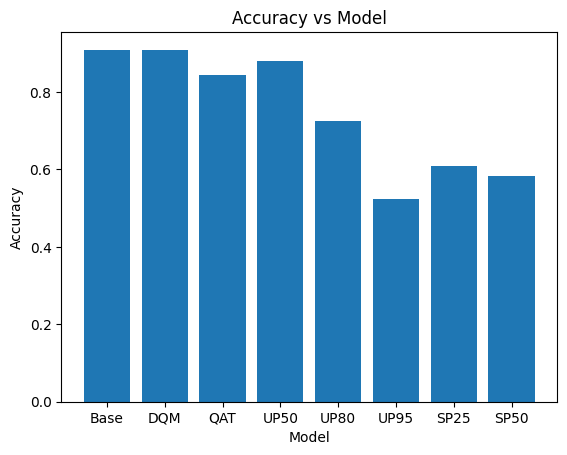

In [130]:
models = {
    'Base': baseline_eval,
    'DQM': dynamic_quantized_model_int8,
    'QAT': qat_eval1,
    'UP50': unstructured_pruning_eval, 
    'UP80': unstructured_pruning_eval_80,
    'UP95': unstructured_pruning_eval_95, 
    'SP25': structured_pruning_eval_25, 
    'SP50': structured_pruning_eval_50
}

def plot_bar_for_feature(feature, y=None):
    x = models.keys()
    if y is None:
        y = [d[feature] for m, d in models.items()]
    print(y)

    # Create bar chart
    plt.bar(x, y)

    # Add labels and title
    plt.xlabel('Model')
    plt.ylabel(feature)
    plt.title(f'{feature} vs Model')

    # Show the plot
    plt.show()

plot_bar_for_feature('Accuracy')


[49.08145093917847, 325.7528250217438, 171.02957320213318, 50.64371418952942, 50.3182098865509, 50.72351622581482, 49.85356116294861, 49.87715196609497]


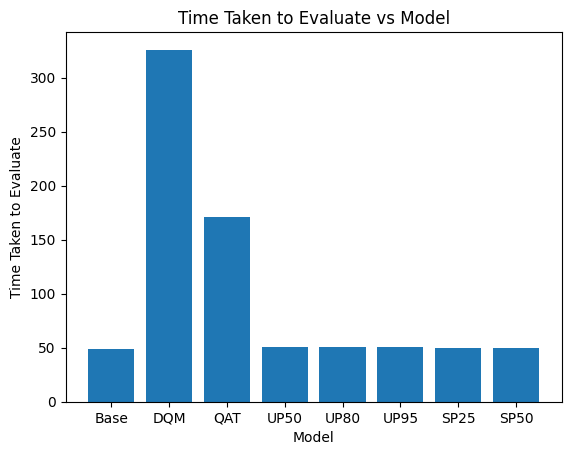

In [126]:
plot_bar_for_feature('Time Taken to Evaluate')

[66955010, 23854080, 66955010, 66955010, 66955010, 66955010, 66955010, 66955010]


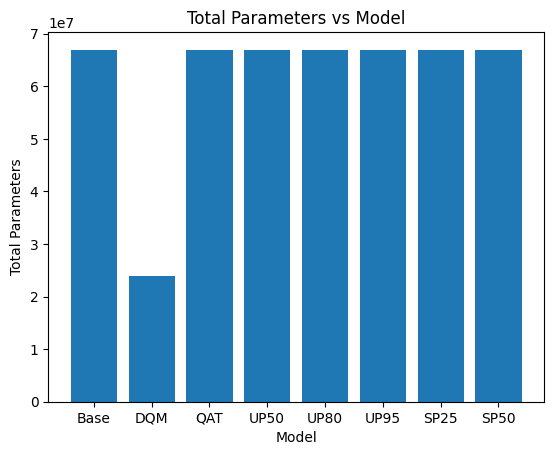

In [127]:
plot_bar_for_feature('Total Parameters')

[267853258, 138706266, 268757582, 267853258, 267853258, 267853258, 267853258, 267853258]


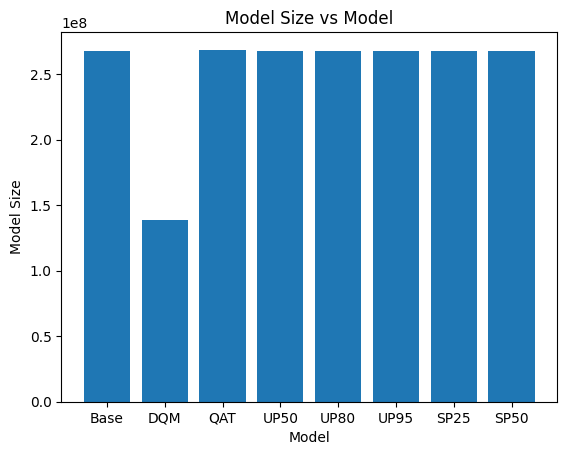

In [128]:
plot_bar_for_feature('Model Size')

[255.45147132873535, 132.2875919342041, 256.3253116607666, 866.02, 619.64, 496.44, 214.39078330993652, 173.32535362243652]


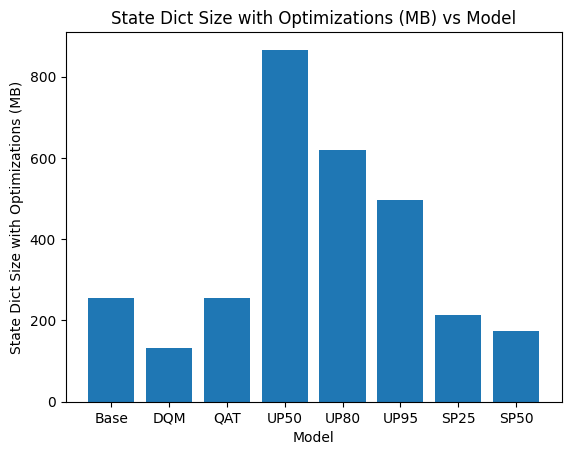

In [132]:
'''
baseline_eval
dynamic_quantized_model_int8
qat_eval1
unstructured_pruning_eval (50%)
unstructured_pruning_eval_80
unstructured_pruning_eval_95
structured_pruning_eval_25
structured_pruning_eval_50'''

plot_bar_for_feature(
    'State Dict Size with Optimizations (MB)',
    # values that are "hard coded" are just from output of cell
    y=[baseline_eval['State Dict Size (MB)'], 
       dynamic_quantized_model_int8['State Dict Size (MB)'], 
       qat_eval1['State Dict Size (MB)'],
       866.02, 
       619.64, 
       496.44, 
       214.39078330993652, 
       173.32535362243652]
)